In [6]:
import yfinance as yf
import pandas as pd
import pandas_datareader as pdr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


# 1. Create The Dataset

#### 1.1 S&P500

In [7]:
start = datetime(2006, 1, 1)
end = datetime(2026, 7, 11)

In [14]:
sp500 = yf.Ticker("^GSPC")
sp500_data = sp500.history(start=start, end=end)["Close"].reset_index()
sp500_data.columns = ["Date", "SP500_Price"]

sp500_data["SP500_Return_5d"] = sp500_data["SP500_Price"].pct_change(5)
sp500_data["SP500_Return_21d"] = sp500_data["SP500_Price"].pct_change(21)
sp500_data["SP500_Return_63d"] = sp500_data["SP500_Price"].pct_change(63)

Gold and oil are classic crisis indicators :-

    - Gold rises during fear/uncertainty (safe haven)
    - Oil drops during economic slowdowns, spikes before inflation crashes

In [18]:
sp500_data["future_return"] = sp500_data["SP500_Price"].pct_change(63).shift(-63)
sp500_data["crash"] = (sp500_data["future_return"] < -0.10).astype(int)
sp500_data = sp500_data.dropna(subset=["future_return"])
print(sp500_data["crash"].value_counts())
print(sp500_data["crash"].value_counts(normalize=True))

crash
0    4796
1     302
Name: count, dtype: int64
crash
0    0.940761
1    0.059239
Name: proportion, dtype: float64


In [19]:
sp500_data = sp500_data.dropna(subset=["future_return"])

302 day has been considered as a crash under our crash assumption , which are 10 months for over the last 20 year

the 6 major crash period:

- 2008 Financial Crisis
- 2011 European Debt Crisis
- 2015-2016 China slowdown
- 2018 Q4 correction
- 2020 COVID crash
- 2022 Rate hike crash

94% no crash
, 6% crash

the class are imbalanced , which means that we are going to use scale_pos_weight for tree models , or class balance = "Blanaced" for linear model

#### 1.2 Vix

popular measure of the stock market's expectation of volatility based on S&P 500 index options.

In [20]:
vix = pdr.get_data_fred("VIXCLS",start,end).reset_index()
vix.columns = ["Date","VIX"]

In [21]:
print(vix.head())
print(vix.shape)

        Date    VIX
0 2006-01-02    NaN
1 2006-01-03  11.14
2 2006-01-04  11.37
3 2006-01-05  11.31
4 2006-01-06  11.00
(5354, 2)


#### 1.3 Gold 

In [22]:
xau = yf.Ticker("GC=F")
gold = xau.history(start=start, end=end)["Close"].reset_index()
gold.columns = ["Date", "Gold_Price"]

gold["Gold_Return_63d"] = gold["Gold_Price"].pct_change(63)

gold["Gold_Return_21d"] = gold["Gold_Price"].pct_change(21)
gold["Gold_Return_5d"] = gold["Gold_Price"].pct_change(5)

#### 1.4 Oil

In [23]:
oil = yf.Ticker("CL=F")
oil_data = oil.history(start=start, end=end)["Close"].reset_index()
oil_data.columns = ["Date", "Oil_Price"]

oil_data["Oil_Return_63d"] = oil_data["Oil_Price"].pct_change(63)
oil_data["Oil_Return_21d"] = oil_data["Oil_Price"].pct_change(21)
oil_data["Oil_Return_5d"] = oil_data["Oil_Price"].pct_change(5)

#### 1.5 Yield Curve

In [24]:
t10 = pdr.get_data_fred("GS10",start,end).reset_index()
t10.columns = ["Date","T10Y"]

t2 = pdr.get_data_fred("GS2",start,end).reset_index()
t2.columns = ("Date","T2Y")

#### 1.6 FED Rate

In [25]:
fed = pdr.get_data_fred("FEDFUNDS", start, end).reset_index()
fed.columns = ["Date", "Fed_Rate"]

#### 1.7 CPI

In [26]:
cpi = pdr.get_data_fred("CPIAUCSL", start, end).reset_index()
cpi.columns = ["Date", "CPI"]

#### 1.8 Unemployment

In [27]:
unemp = pdr.get_data_fred("UNRATE", start, end).reset_index()
unemp.columns = ["Date", "Unemployment"]

In [28]:
print(t10.shape, t2.shape, fed.shape, cpi.shape, unemp.shape)


(246, 2) (246, 2) (246, 2) (245, 2) (246, 2)


#### 1.9 Merge 

In [30]:
for df in [sp500_data,vix,gold,oil_data,t10,t2,fed,cpi,unemp]:
    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None) if df["Date"].dt.tz is not None else df["Date"]
    df.sort_values("Date", inplace=True)

In [32]:
master = sp500_data.copy()

In [33]:
for df, name in [(vix, "vix"), (gold, "gold"), (oil_data, "oil"),
                  (t10, "t10"), (t2, "t2"), (fed, "fed"),
                  (cpi, "cpi"), (unemp, "unemp")]:
    master = pd.merge_asof(master, df, on="Date", direction="backward")

print(master.shape)
print(master.isnull().sum())

(5098, 21)
Date                 0
SP500_Price          0
SP500_Return_5d      5
SP500_Return_21d    21
SP500_Return_63d    63
future_return        0
crash                0
VIX                  0
Gold_Price           0
Gold_Return_63d     63
Gold_Return_21d     21
Gold_Return_5d       5
Oil_Price            0
Oil_Return_63d      63
Oil_Return_21d      21
Oil_Return_5d        5
T10Y                 0
T2Y                  0
Fed_Rate             0
CPI                 23
Unemployment        23
dtype: int64


In [38]:
master = master.dropna(subset=["CPI", "Unemployment","SP500_Return_5d","SP500_Return_21d",
                              "SP500_Return_63d","Gold_Return_63d","Gold_Return_21d",
                              "Gold_Return_5d","Oil_Return_63d","Oil_Return_21d",
                              "Oil_Return_5d"])
master["Yield_Spread"] = master["T10Y"] - master["T2Y"]
print(master.shape)

(5012, 22)


# 2. Review the Data Structure

In [39]:
print (master.columns)

Index(['Date', 'SP500_Price', 'SP500_Return_5d', 'SP500_Return_21d',
       'SP500_Return_63d', 'future_return', 'crash', 'VIX', 'Gold_Price',
       'Gold_Return_63d', 'Gold_Return_21d', 'Gold_Return_5d', 'Oil_Price',
       'Oil_Return_63d', 'Oil_Return_21d', 'Oil_Return_5d', 'T10Y', 'T2Y',
       'Fed_Rate', 'CPI', 'Unemployment', 'Yield_Spread'],
      dtype='object')


In [43]:
print(master.isna().sum())

Date                0
SP500_Price         0
SP500_Return_5d     0
SP500_Return_21d    0
SP500_Return_63d    0
future_return       0
crash               0
VIX                 0
Gold_Price          0
Gold_Return_63d     0
Gold_Return_21d     0
Gold_Return_5d      0
Oil_Price           0
Oil_Return_63d      0
Oil_Return_21d      0
Oil_Return_5d       0
T10Y                0
T2Y                 0
Fed_Rate            0
CPI                 0
Unemployment        0
Yield_Spread        0
dtype: int64


# 3. Explanatory Data Analysis (EDA)

In [57]:
cols = master.columns.tolist()

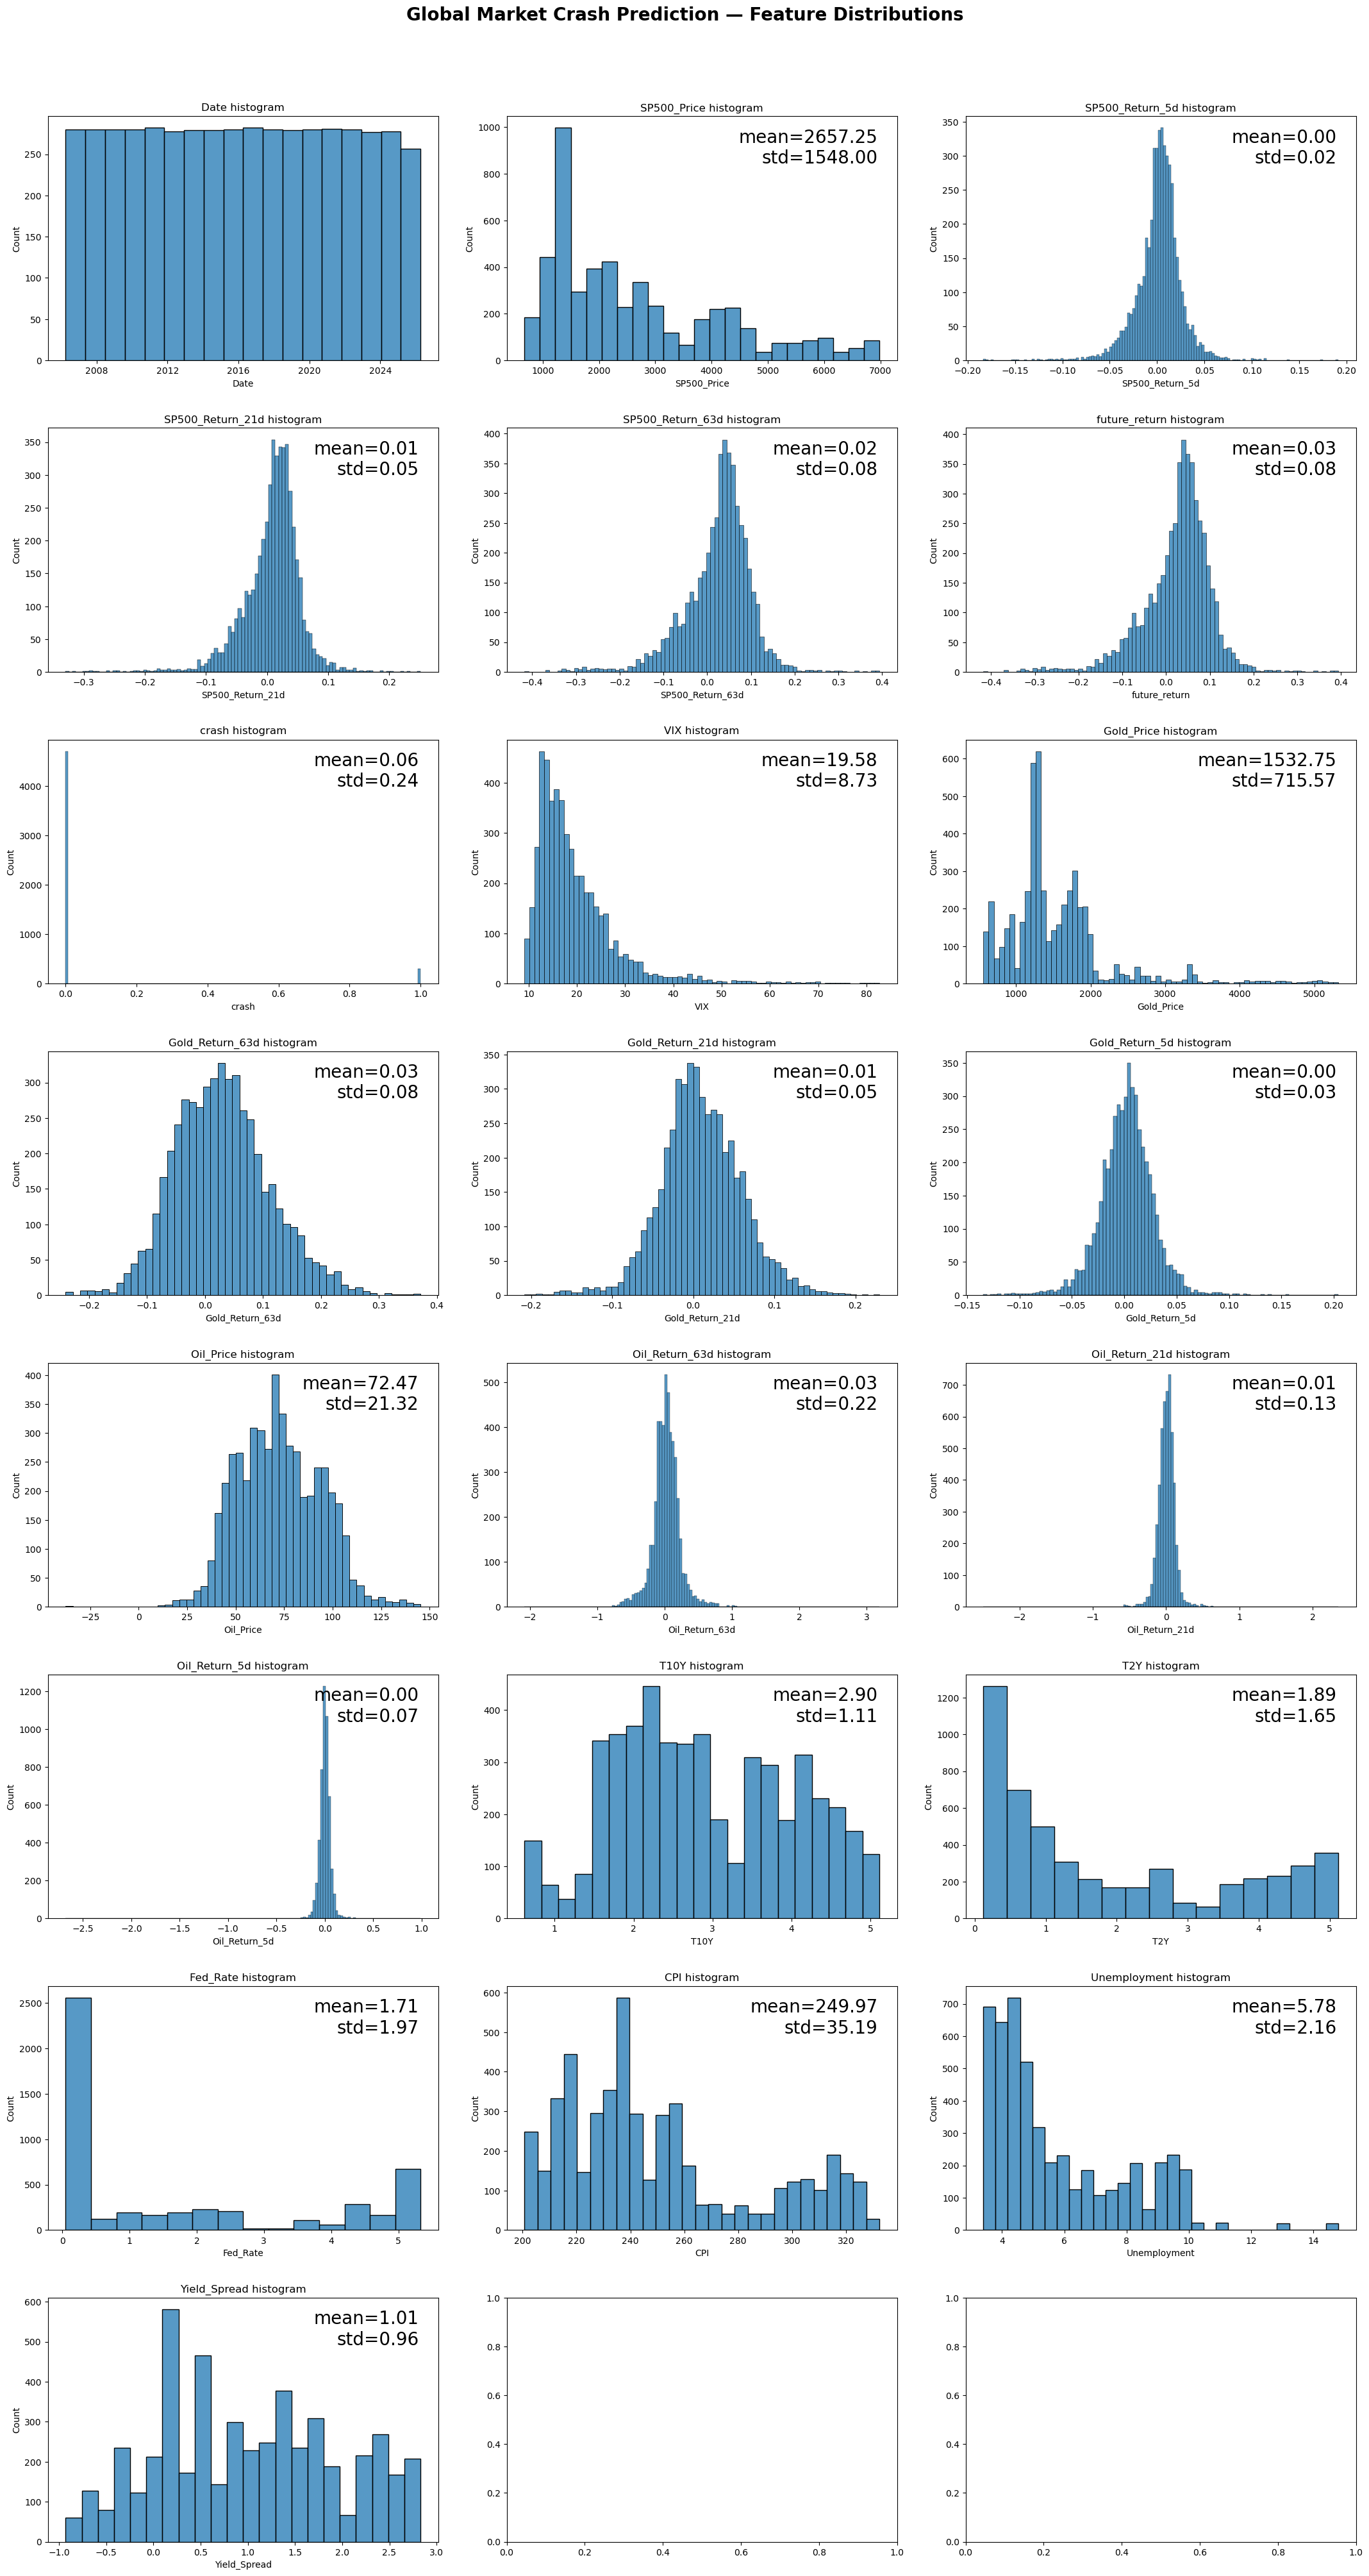

In [72]:
fig, ax = plt.subplots(8, 3, figsize=(22, 40))
ax = ax.flatten()
fig.suptitle("Global Market Crash Prediction — Feature Distributions",
             fontsize=20, fontweight="bold", y=1.01)

for i, name in enumerate(cols):
    sns.histplot(data=master, x=name, ax=ax[i])
    ax[i].set_title(f"{name} histogram")
    if master[name].dtype != "object" and name != "Date":
        mean = master[name].mean()
        std = master[name].std()
        ax[i].text(0.95, 0.95, f"mean={mean:.2f}\nstd={std:.2f}",
                   transform=ax[i].transAxes,
                   ha="right", va="top", fontsize=20)

plt.tight_layout(pad=3.0)
plt.savefig("charts/feature_distributions.png", bbox_inches="tight", dpi=150)
plt.show()


## 3. Statistical Analysis

### 3.1 Descriptive Statistics

| Feature | Mean | Std | Min | Max | Skewness |
|---|---|---|---|---|---|
| SP500_Return_5d | 0.00 | 0.02 | -0.20 | 0.20 | slight left skew |
| SP500_Return_21d | 0.01 | 0.05 | -0.30 | 0.25 | slight left skew |
| SP500_Return_63d | 0.02 | 0.08 | -0.40 | 0.40 | slight left skew |
| VIX | 19.58 | 8.73 | 9.00 | 80.00 | strong right skew |
| Gold_Return_5d | 0.00 | 0.03 | -0.15 | 0.15 | approximately normal |
| Gold_Return_21d | 0.01 | 0.05 | -0.20 | 0.20 | approximately normal |
| Gold_Return_63d | 0.03 | 0.08 | -0.20 | 0.35 | approximately normal |
| Oil_Return_5d | 0.00 | 0.07 | -2.50 | 1.00 | extreme left skew (artifact) |
| Oil_Return_21d | 0.01 | 0.13 | -2.50 | 2.50 | extreme left skew (artifact) |
| Oil_Return_63d | 0.03 | 0.22 | -2.00 | 3.00 | extreme left skew (artifact) |
| T10Y | 2.90 | 1.11 | 0.50 | 5.00 | approximately normal |
| T2Y | 1.89 | 1.65 | 0.10 | 5.00 | right skew (ZIRP effect) |
| Fed_Rate | 1.71 | 1.97 | 0.00 | 5.50 | strong right skew (two regimes) |
| CPI | 249.97 | 35.19 | 200.00 | 325.00 | right skew |
| Unemployment | 5.78 | 2.16 | 3.50 | 15.00 | strong right skew (COVID spike) |
| Yield_Spread | 1.01 | 0.96 | -1.00 | 3.00 | slight left skew |

---

### 3.2 Class Imbalance Analysis

| Class | Count | Proportion |
|---|---|---|
| 0 — No Crash | 4,796 | 94.0% |
| 1 — Crash | 302 | 6.0% |

**Implication:** Standard accuracy is misleading here — a model predicting "no crash" 
every single time achieves 94% accuracy while being completely useless. 
AUC-ROC is the correct evaluation metric, same approach used in the credit card project.

**Handling strategy:**
- LightGBM → `scale_pos_weight = 4796 / 302 ≈ 15.9`
- Logistic Regression → `class_weight="balanced"`

---

### 3.3 Regime Analysis — Two Distinct Market Regimes

The dataset spans 2006–2026, covering two fundamentally different macro regimes:

| Regime | Period | Fed Rate | VIX (avg) | Yield Spread |
|---|---|---|---|---|
| Pre-GFC / Normal | 2006–2008 | 2–5% | ~20 | positive |
| Post-GFC ZIRP | 2009–2021 | ~0% | ~15 | positive |
| Post-COVID Hikes | 2022–2026 | 3–5.5% | ~20 | negative (inverted) |

**Implication:** Features like `Fed_Rate` and `T2Y` will behave very differently 
across regimes — the model needs to learn from all three periods, which the 
chronological train/test split will respect naturally.

---

### 3.4 Anomaly Detection — Oil Futures Artifact

`Oil_Return_5d`, `Oil_Return_21d`, and `Oil_Return_63d` all show an extreme spike 
near -1 to -2.5 on the x-axis — well outside the expected range for genuine oil 
price moves. This is a known artifact of the `CL=F` futures ticker in yfinance, 
caused by contract roll dates where the price difference between expiring and 
new contracts is recorded as a return. 

**Options before modeling:**
- Clip returns to a reasonable range (e.g., `-0.5` to `0.5` for 5d/21d)
- Winsorize at the 1st and 99th percentile
- Drop oil return features entirely if the artifact cannot be cleanly resolved

---

### 3.5 Yield Curve Inversion — Key Crash Signal

`Yield_Spread = T10Y - T2Y` has a mean of 1.01 and std of 0.96, with a left tail 
reaching -1.0. Negative values indicate yield curve inversion — historically one 
of the most reliable recession predictors:

| Inversion Period | Subsequent Event |
|---|---|
| 2006–2007 | Global Financial Crisis (2008) |
| 2019 | COVID crash (2020) |
| 2022–2023 | Ongoing rate hike impact |

An inverted yield spread is therefore expected to be one of the top feature 
importances after modeling.

---

### 3.6 VIX — Fear Index as Crash Predictor

VIX mean of 19.58 with std of 8.73 and a right tail reaching 80 (COVID spike) 
indicates that extreme VIX readings are rare but highly concentrated around 
crash periods. A VIX reading above 40 has historically coincided with or 
immediately preceded major market dislocations:

| VIX Spike | Event |
|---|---|
| ~80 | COVID crash (March 2020) |
| ~60 | Global Financial Crisis (2008) |
| ~40 | 2011 European Debt Crisis |
| ~36 | 2018 Q4 correction |

In [73]:
col = ["SP500_Price","Gold_Price","Oil_Price","Yield_Spread","CPI","Unemployment"] 

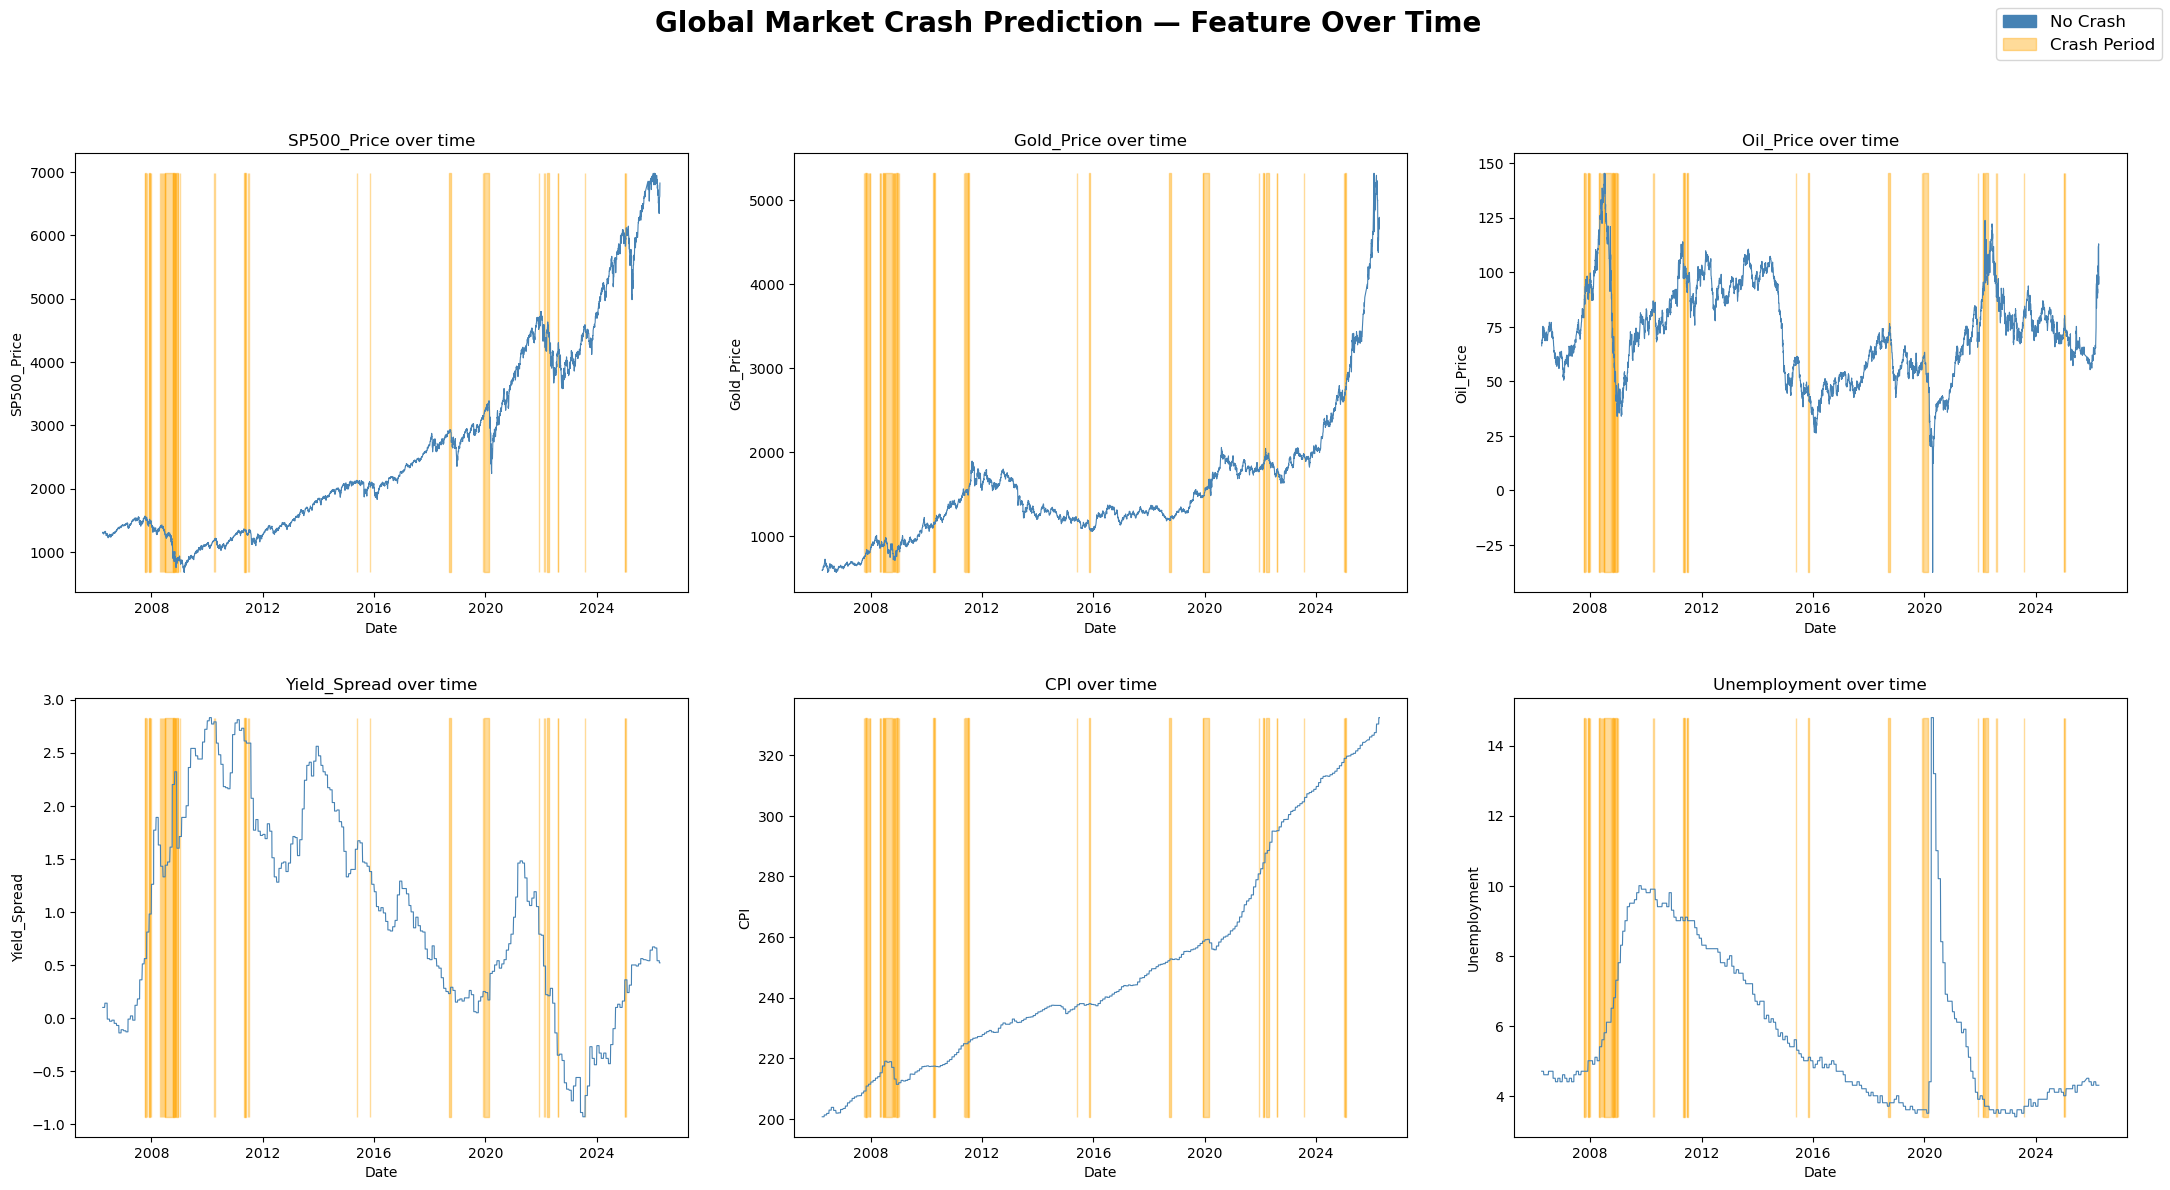

In [83]:
import matplotlib.patches as mpatches

cols = ["SP500_Price", "Gold_Price", "Oil_Price", "Yield_Spread", "CPI", "Unemployment"]

fig, ax = plt.subplots(2, 3, figsize=(22, 12))
ax = ax.flatten()
fig.suptitle("Global Market Crash Prediction — Feature Over Time",
             fontsize=20, fontweight="bold", y=1.01)

for i, name in enumerate(cols):
    # Plot full series in blue
    ax[i].plot(master["Date"], master[name], color="steelblue", linewidth=0.8)
    
    # Highlight crash periods in orange
    crash_mask = master["crash"] == 1
    ax[i].fill_between(master["Date"], 
                        master[name].min(), 
                        master[name].max(),
                        where=crash_mask,
                        color="orange", alpha=0.4)
    
    ax[i].set_title(f"{name} over time", fontsize=12)
    ax[i].set_xlabel("Date")
    ax[i].set_ylabel(name)

# Legend
blue_patch = mpatches.Patch(color="steelblue", label="No Crash")
orange_patch = mpatches.Patch(color="orange", alpha=0.4, label="Crash Period")
fig.legend(handles=[blue_patch, orange_patch], loc="upper right", fontsize=12)

plt.tight_layout(pad=3.0)
plt.savefig("charts/features_over_time.png", bbox_inches="tight", dpi=150)
plt.show()